In [2]:
from sklearn.linear_model import LinearRegression
import numpy as np
# Example data
X = np.array([[1], [2], [3], [4], [5]]) 
y = np.array([10, 20, 30, 40, 50]) # Create and fit the model
model = LinearRegression()
model.fit(X, y)
# Make a prediction
predicted_score = model.predict([[6]]) 
print(predicted_score)

[60.]


In [8]:
import numpy as np
scores = [80, 90, 70, 85, 75]
# Mean, median, mode, standard deviation
mean_score = np.mean(scores)
median_score = np.median(scores)
std_deviation = np.std(scores)
print(std_deviation)

7.0710678118654755


In [1]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
import datetime

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn for Preprocessing, Metrics, Model Selection ---
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# --- Machine Learning Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb # XGBoost library

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) # Format floats to 2 decimal places
sns.set_style('whitegrid')

print("--- 1. Project Setup & Synthetic Data Generation for Grocery Churn ---")

# --- Configuration for Synthetic Data ---
N_CUSTOMERS = 2000
START_DATE = datetime.datetime(2022, 1, 1)
END_DATE = datetime.datetime(2024, 12, 31) # Approx 3 years of data
OBSERVATION_DATE = datetime.datetime(2024, 7, 1) # Date we are making predictions from
CHURN_WINDOW_DAYS = 90 # If no purchase in last 90 days before OBS_DATE, considered for churn analysis
PREDICTION_WINDOW_DAYS = 60 # Predict churn in the next 60 days after OBS_DATE

np.random.seed(42) # For reproducibility

# --- Generate Customer Data ---
customers_data = {
    'CustomerID': range(1, N_CUSTOMERS + 1),
    'Age': np.random.randint(18, 75, size=N_CUSTOMERS),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], size=N_CUSTOMERS, p=[0.48, 0.48, 0.04]),
    'Location': np.random.choice(['Urban', 'Suburban', 'Rural'], size=N_CUSTOMERS, p=[0.5, 0.3, 0.2]),
    'LoyaltyMember': np.random.choice([True, False], size=N_CUSTOMERS, p=[0.65, 0.35]),
    'SignupDate': [START_DATE + datetime.timedelta(days=np.random.randint(0, (OBSERVATION_DATE - START_DATE).days - 180)) for _ in range(N_CUSTOMERS)]
}
customers_df = pd.DataFrame(customers_data)
customers_df['SignupDate'] = pd.to_datetime(customers_df['SignupDate'])

# --- Generate Transaction Data ---
transactions_list = []
for _, customer in customers_df.iterrows():
    customer_id = customer['CustomerID']
    signup_date = customer['SignupDate']

    # Simulate different purchasing behaviors
    if customer['Age'] < 30 and customer['LoyaltyMember']: # Younger loyal customers might shop more frequently
        avg_days_between_purchases = np.random.uniform(3, 10)
        avg_items_per_purchase = np.random.randint(5, 15)
        avg_spend_per_item = np.random.uniform(2, 6)
    elif customer['Location'] == 'Urban':
        avg_days_between_purchases = np.random.uniform(5, 15)
        avg_items_per_purchase = np.random.randint(3, 10)
        avg_spend_per_item = np.random.uniform(2.5, 7)
    else:
        avg_days_between_purchases = np.random.uniform(7, 20)
        avg_items_per_purchase = np.random.randint(2, 8)
        avg_spend_per_item = np.random.uniform(3, 8)

    # Simulate a potential drop-off for some customers (to create churners)
    likely_to_churn_factor = np.random.rand() # Random factor for churn likelihood

    current_date = signup_date
    while current_date < END_DATE: # Generate transactions up to end date
        days_to_next_purchase = np.random.poisson(avg_days_between_purchases)
        current_date += datetime.timedelta(days=days_to_next_purchase)
        if current_date > END_DATE:
            break

        # Simulate drop-off: if customer is "likely to churn" and date is past a certain point
        if likely_to_churn_factor < 0.20 and current_date > (OBSERVATION_DATE - datetime.timedelta(days=np.random.randint(60, 200))):
            if np.random.rand() < 0.8: # 80% chance of stopping purchases if "marked" for churn
                break

        num_items = np.random.poisson(avg_items_per_purchase)
        if num_items == 0: num_items = 1

        transaction_amount = 0
        for _ in range(num_items):
            transaction_amount += np.random.normal(avg_spend_per_item, avg_spend_per_item * 0.3)
        transaction_amount = max(1.0, transaction_amount) # Ensure positive amount

        transactions_list.append({
            'TransactionID': len(transactions_list) + 1,
            'CustomerID': customer_id,
            'TransactionDate': current_date,
            'TransactionAmount': transaction_amount,
            'NumberOfItems': num_items
        })

transactions_df = pd.DataFrame(transactions_list)
transactions_df['TransactionDate'] = pd.to_datetime(transactions_df['TransactionDate'])

print(f"\nGenerated {len(customers_df)} customers and {len(transactions_df)} transactions.")
print("\n--- Sample Customer Data (First 5 rows) ---")
print(customers_df.head())
print("\n--- Sample Transaction Data (First 5 rows) ---")
print(transactions_df.head())

# --- Define Churn ---
# Churn definition: A customer is considered churned if they make no purchases
# within the PREDICTION_WINDOW_DAYS *after* the OBSERVATION_DATE.
# We first identify customers active around the observation period.

# Transactions before or on observation date
transactions_before_obs = transactions_df[transactions_df['TransactionDate'] <= OBSERVATION_DATE]
last_purchase_before_obs = transactions_before_obs.groupby('CustomerID')['TransactionDate'].max().reset_index()
last_purchase_before_obs.rename(columns={'TransactionDate': 'LastPurchaseDateBeforeObs'}, inplace=True)

# Merge with customer data
customers_df = pd.merge(customers_df, last_purchase_before_obs, on='CustomerID', how='left')

# Identify customers who were "active" recently enough to be considered for churn
# e.g., made a purchase within CHURN_WINDOW_DAYS leading up to OBSERVATION_DATE
customers_df['PotentiallyActive'] = (OBSERVATION_DATE - customers_df['LastPurchaseDateBeforeObs']).dt.days <= CHURN_WINDOW_DAYS
# We will focus on these potentially active customers for churn prediction.

# Transactions after observation date
transactions_after_obs = transactions_df[transactions_df['TransactionDate'] > OBSERVATION_DATE]

# Identify if a customer made any purchase in the prediction window
churn_target_df = transactions_after_obs[
    (transactions_after_obs['TransactionDate'] > OBSERVATION_DATE) &
    (transactions_after_obs['TransactionDate'] <= OBSERVATION_DATE + datetime.timedelta(days=PREDICTION_WINDOW_DAYS))
]
customers_with_purchase_in_pred_window = churn_target_df['CustomerID'].unique()

# Create the churn label
customers_df['Churn'] = 1 # Assume churned
customers_df.loc[customers_df['CustomerID'].isin(customers_with_purchase_in_pred_window), 'Churn'] = 0 # Not churned if made a purchase

# Filter for customers who were "PotentiallyActive" to make the churn definition more meaningful
# And those who signed up long enough ago to have a purchase history
MIN_TENURE_DAYS = 90 # e.g., customer must be signed up for at least 90 days before observation
customers_df['TenureAtObs'] = (OBSERVATION_DATE - customers_df['SignupDate']).dt.days
relevant_customers_df = customers_df[
    (customers_df['PotentiallyActive']) &
    (customers_df['TenureAtObs'] >= MIN_TENURE_DAYS)
].copy()


print(f"\nNumber of relevant customers for churn analysis: {len(relevant_customers_df)}")
if not relevant_customers_df.empty:
    print("\nChurn distribution among relevant customers:")
    print(relevant_customers_df['Churn'].value_counts(normalize=True))
else:
    print("No relevant customers found for churn analysis based on current data generation parameters.")
    print("Consider adjusting N_CUSTOMERS, date ranges, or churn logic if this is unexpected.")


print("\n--- Data Setup Complete ---")
# 'relevant_customers_df' will be the base for our feature engineering and modeling.
# It contains customer info and the 'Churn' label.
# 'transactions_before_obs' will be used to engineer features.

--- 1. Project Setup & Synthetic Data Generation for Grocery Churn ---

Generated 2000 customers and 135301 transactions.

--- Sample Customer Data (First 5 rows) ---
   CustomerID  Age  Gender  Location  LoyaltyMember SignupDate
0           1   56  Female  Suburban          False 2022-09-26
1           2   69  Female     Urban          False 2023-11-29
2           3   46  Female     Urban           True 2022-05-11
3           4   32    Male     Rural           True 2022-12-17
4           5   60  Female  Suburban           True 2022-06-29

--- Sample Transaction Data (First 5 rows) ---
   TransactionID  CustomerID TransactionDate  TransactionAmount  NumberOfItems
0              1           1      2022-10-16               9.17              3
1              2           1      2022-10-26              14.87              5
2              3           1      2022-11-05               7.03              2
3              4           1      2022-11-20              15.37              5
4           

Okay, let's proceed with the Data Exploration (EDA) for our synthetic grocery store customer data.

The primary DataFrame we'll be exploring for churn-related insights is relevant_customers_df, which we created in the previous step. We'll also look at transactions_before_obs to understand purchase patterns, although detailed transactional features will be engineered in the next step.
This EDA block will help us visualize the churn distribution and see how different customer attributes (like age, location, loyalty status, tenure, and recency) and basic transaction patterns relate to the likelihood of a customer churning.




--- 2. Data Exploration (EDA) for Grocery Churn ---

Analyzing the target variable: Churn


/var/folders/k9/336nhjx9537500djk09zcj340000gn/T/ipykernel_14204/1450398308.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=relevant_customers_df, palette=['skyblue', 'salmon'])


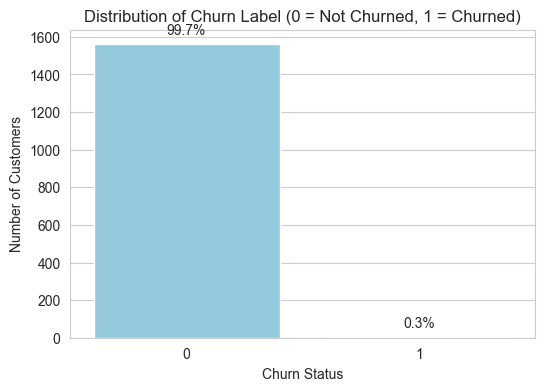

Churn
0   1.00
1   0.00
Name: proportion, dtype: float64


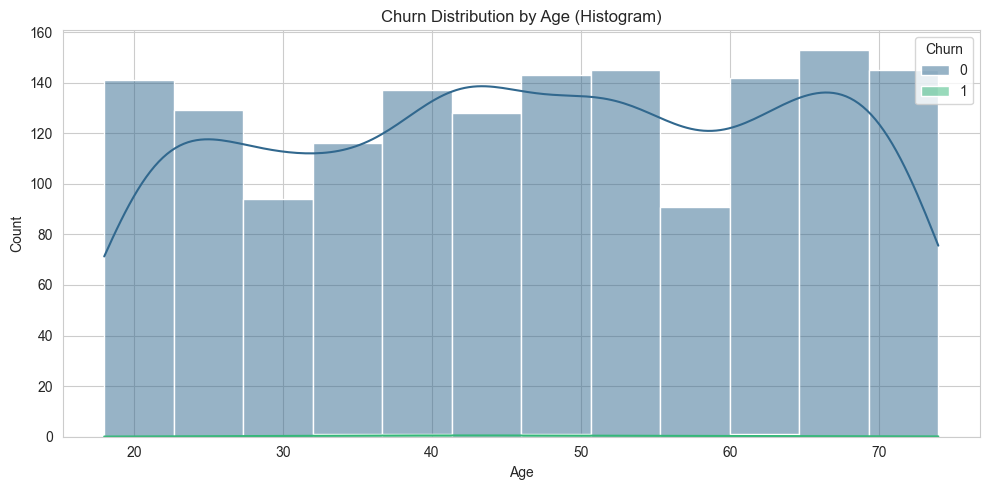

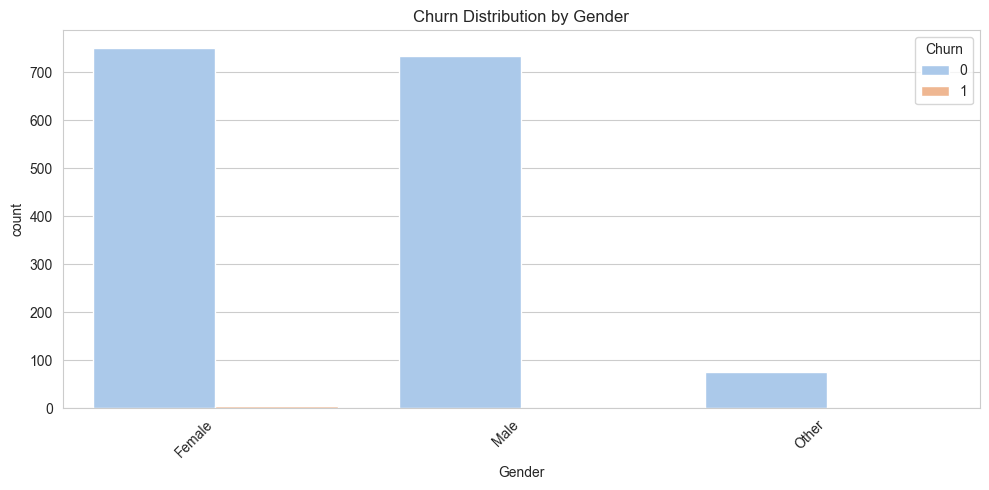

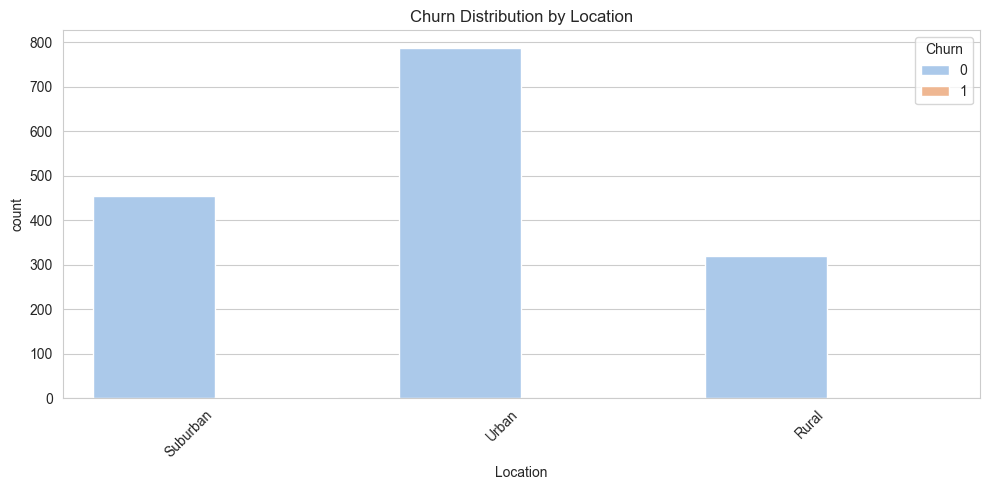

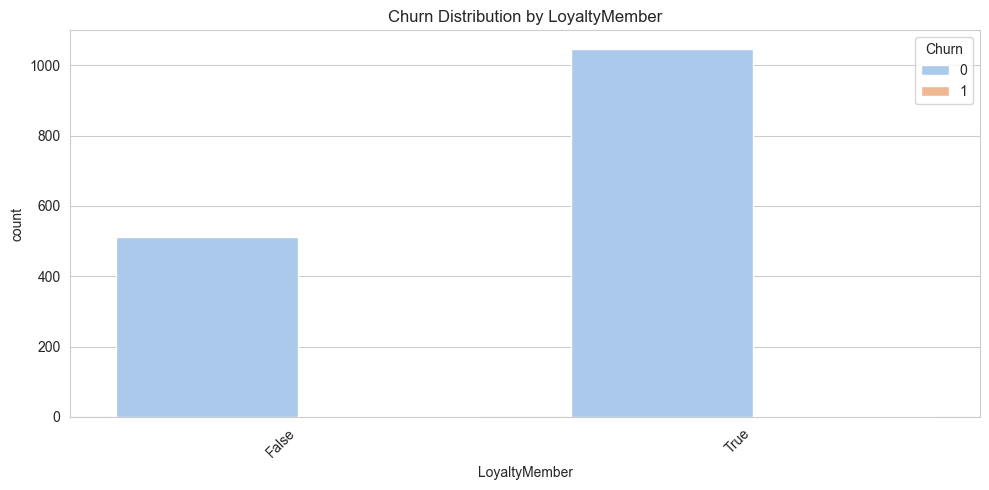

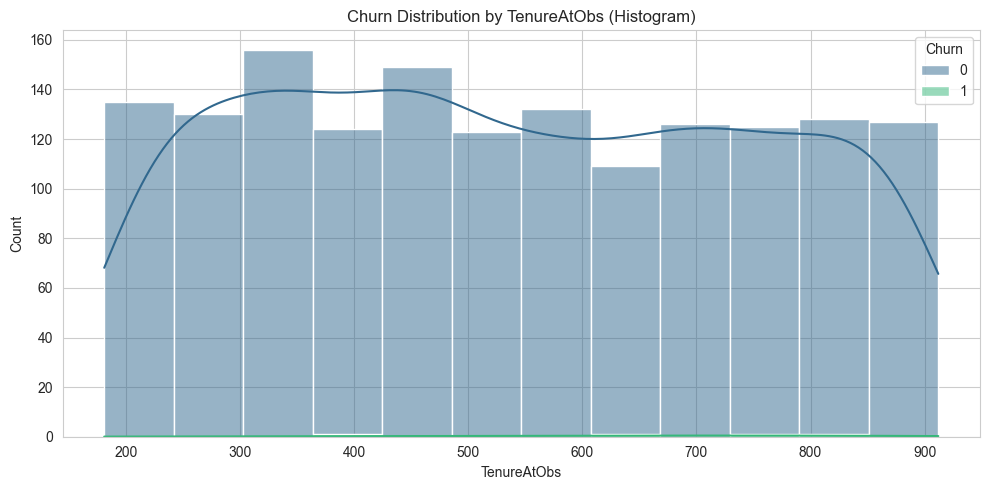

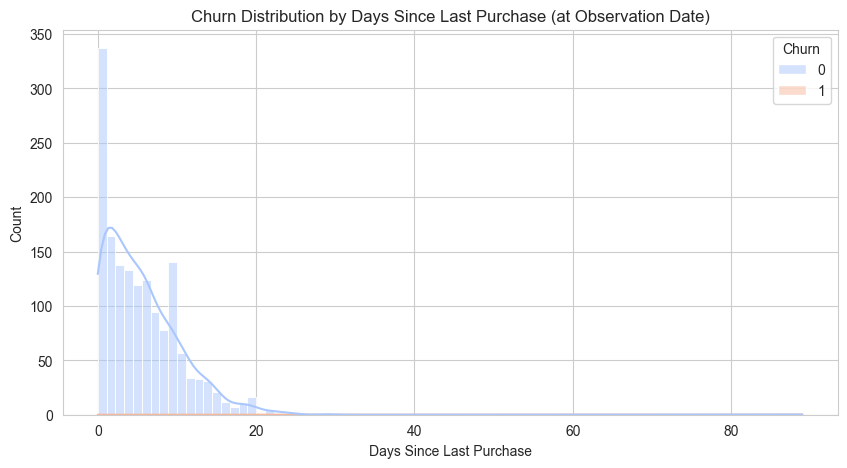


Analyzing basic transaction patterns (before observation date)...


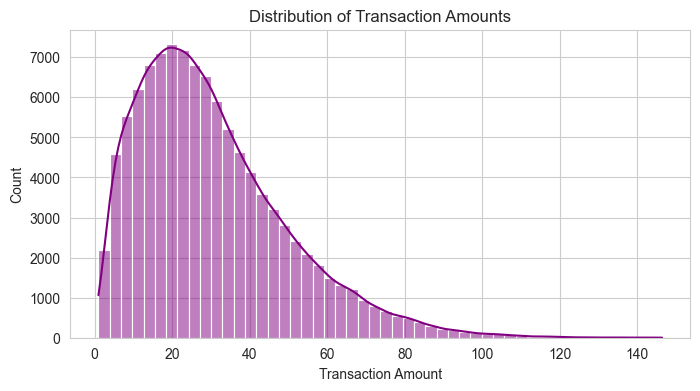

/var/folders/k9/336nhjx9537500djk09zcj340000gn/T/ipykernel_14204/1450398308.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='NumberOfTransactions', data=eda_df_trans, palette='PRGn')


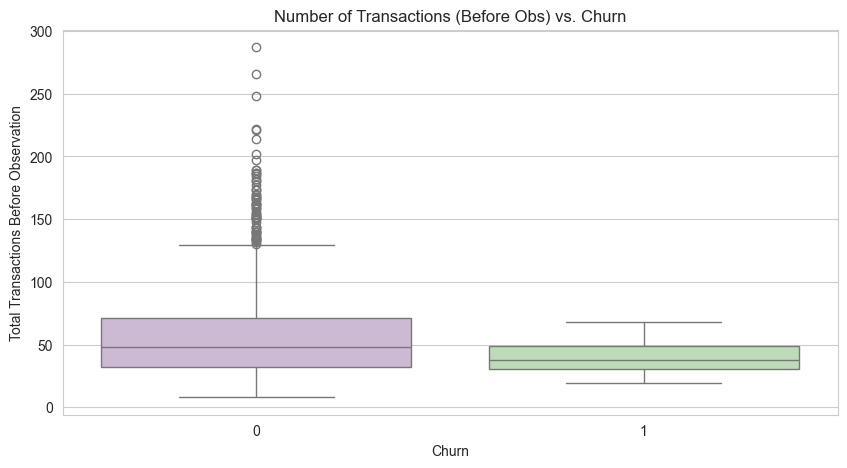

/var/folders/k9/336nhjx9537500djk09zcj340000gn/T/ipykernel_14204/1450398308.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='AvgTransactionAmount', data=eda_df_avg_trans, palette='Spectral')


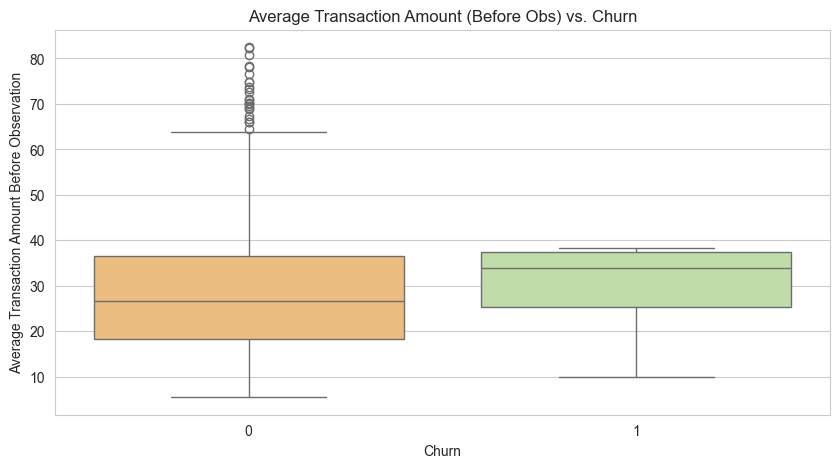


Missing values in the 'relevant_customers_df' (used for modeling):
No missing values found in 'relevant_customers_df'.

--- EDA for Grocery Churn Complete ---


In [2]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
import datetime

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_style('whitegrid')

# This block assumes 'relevant_customers_df' and 'transactions_before_obs'
# are available from the previous step (1. Project Setup & Synthetic Data Generation).
# Also assumes OBSERVATION_DATE is defined.

if 'relevant_customers_df' not in globals() or 'transactions_before_obs' not in globals() or 'OBSERVATION_DATE' not in globals():
    print("Warning: 'relevant_customers_df' or 'transactions_before_obs' or 'OBSERVATION_DATE' not found.")
    print("Please run the '1. Project Setup & Synthetic Data Generation' block first.")
    # Fallback: Create minimal dummy data for this block to run
    OBSERVATION_DATE = datetime.datetime(2024, 7, 1)
    N_RELEVANT_CUSTOMERS = 500
    relevant_customers_data = {
        'CustomerID': range(1, N_RELEVANT_CUSTOMERS + 1),
        'Age': np.random.randint(18, 75, size=N_RELEVANT_CUSTOMERS),
        'Gender': np.random.choice(['Male', 'Female', 'Other'], size=N_RELEVANT_CUSTOMERS, p=[0.48, 0.48, 0.04]),
        'Location': np.random.choice(['Urban', 'Suburban', 'Rural'], size=N_RELEVANT_CUSTOMERS, p=[0.5, 0.3, 0.2]),
        'LoyaltyMember': np.random.choice([True, False], size=N_RELEVANT_CUSTOMERS, p=[0.65, 0.35]),
        'SignupDate': [OBSERVATION_DATE - datetime.timedelta(days=np.random.randint(90, 700)) for _ in range(N_RELEVANT_CUSTOMERS)],
        'LastPurchaseDateBeforeObs': [OBSERVATION_DATE - datetime.timedelta(days=np.random.randint(1, 90)) for _ in range(N_RELEVANT_CUSTOMERS)],
        'PotentiallyActive': True,
        'TenureAtObs': np.random.randint(90, 700, size=N_RELEVANT_CUSTOMERS),
        'Churn': np.random.choice([0, 1], size=N_RELEVANT_CUSTOMERS, p=[0.7, 0.3]) # Approx 30% churn rate
    }
    relevant_customers_df = pd.DataFrame(relevant_customers_data)
    
    N_TRANSACTIONS = 5000
    transactions_data = {
        'CustomerID': np.random.choice(relevant_customers_df['CustomerID'], size=N_TRANSACTIONS),
        'TransactionDate': [OBSERVATION_DATE - datetime.timedelta(days=np.random.randint(1, 365)) for _ in range(N_TRANSACTIONS)],
        'TransactionAmount': np.random.lognormal(mean=np.log(25), sigma=0.5, size=N_TRANSACTIONS).clip(1),
        'NumberOfItems': np.random.poisson(5, size=N_TRANSACTIONS) + 1
    }
    transactions_before_obs = pd.DataFrame(transactions_data)
    transactions_before_obs['TransactionDate'] = pd.to_datetime(transactions_before_obs['TransactionDate'])

    print("Using minimal dummy data for EDA demonstration.")

print("\n--- 2. Data Exploration (EDA) for Grocery Churn ---")

# --- 2.1 Target Variable Analysis ('Churn') ---
if not relevant_customers_df.empty and 'Churn' in relevant_customers_df.columns:
    print("\nAnalyzing the target variable: Churn")
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Churn', data=relevant_customers_df, palette=['skyblue', 'salmon'])
    plt.title('Distribution of Churn Label (0 = Not Churned, 1 = Churned)')
    plt.xlabel('Churn Status')
    plt.ylabel('Number of Customers')
    # Show percentages on bars
    total = len(relevant_customers_df['Churn'])
    for p in plt.gca().patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x_val = p.get_x() + p.get_width() / 2
        y_val = p.get_height()
        plt.gca().annotate(percentage, (x_val, y_val), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
    plt.show()

    print(relevant_customers_df['Churn'].value_counts(normalize=True))
else:
    print("Warning: 'relevant_customers_df' is empty or 'Churn' column is missing. Cannot analyze target variable.")

# --- 2.2 Demographic and Static Customer Feature Analysis vs. Churn ---
static_features_to_analyze = ['Age', 'Gender', 'Location', 'LoyaltyMember', 'TenureAtObs']

for feature in static_features_to_analyze:
    if not relevant_customers_df.empty and feature in relevant_customers_df.columns and 'Churn' in relevant_customers_df.columns:
        plt.figure(figsize=(10, 5))
        if relevant_customers_df[feature].dtype == 'object' or relevant_customers_df[feature].nunique() < 15:
            # Categorical or low-cardinality numerical features
            sns.countplot(x=feature, hue='Churn', data=relevant_customers_df, palette='pastel')
            plt.title(f'Churn Distribution by {feature}')
            plt.xticks(rotation=45, ha='right')
        else:
            # Numerical features
            sns.histplot(data=relevant_customers_df, x=feature, hue='Churn', kde=True, multiple="stack", palette='viridis')
            plt.title(f'Churn Distribution by {feature} (Histogram)')
        
        plt.tight_layout()
        plt.show()
    # else:
        # print(f"Skipping EDA for feature '{feature}' as it's missing or 'Churn' label is unavailable.")

# --- 2.3 Recency Analysis (from LastPurchaseDateBeforeObs) ---
if not relevant_customers_df.empty and 'LastPurchaseDateBeforeObs' in relevant_customers_df.columns and 'Churn' in relevant_customers_df.columns:
    relevant_customers_df['DaysSinceLastPurchaseAtObs'] = (OBSERVATION_DATE - pd.to_datetime(relevant_customers_df['LastPurchaseDateBeforeObs'])).dt.days
    
    plt.figure(figsize=(10, 5))
    sns.histplot(data=relevant_customers_df, x='DaysSinceLastPurchaseAtObs', hue='Churn', kde=True, multiple="stack", palette='coolwarm')
    plt.title('Churn Distribution by Days Since Last Purchase (at Observation Date)')
    plt.xlabel('Days Since Last Purchase')
    plt.show()

# --- 2.4 Basic Transactional Insights (from transactions_before_obs) ---
# These are precursors to more detailed feature engineering.
if not transactions_before_obs.empty:
    print("\nAnalyzing basic transaction patterns (before observation date)...")
    
    # Distribution of Transaction Amounts
    plt.figure(figsize=(8, 4))
    sns.histplot(transactions_before_obs['TransactionAmount'], kde=True, bins=50, color='purple')
    plt.title('Distribution of Transaction Amounts')
    plt.xlabel('Transaction Amount')
    plt.show()

    # Number of transactions per customer
    transactions_per_customer = transactions_before_obs.groupby('CustomerID').size().reset_index(name='NumberOfTransactions')
    
    # Merge with relevant_customers_df to see relation with churn
    if not relevant_customers_df.empty and 'Churn' in relevant_customers_df.columns:
        eda_df_trans = pd.merge(relevant_customers_df[['CustomerID', 'Churn']], transactions_per_customer, on='CustomerID', how='left').fillna(0)
        
        plt.figure(figsize=(10, 5))
        sns.boxplot(x='Churn', y='NumberOfTransactions', data=eda_df_trans, palette='PRGn')
        plt.title('Number of Transactions (Before Obs) vs. Churn')
        plt.ylabel('Total Transactions Before Observation')
        plt.show()

        # Average transaction amount per customer
        avg_trans_amount_customer = transactions_before_obs.groupby('CustomerID')['TransactionAmount'].mean().reset_index(name='AvgTransactionAmount')
        eda_df_avg_trans = pd.merge(relevant_customers_df[['CustomerID', 'Churn']], avg_trans_amount_customer, on='CustomerID', how='left').fillna(0)

        plt.figure(figsize=(10, 5))
        sns.boxplot(x='Churn', y='AvgTransactionAmount', data=eda_df_avg_trans, palette='Spectral')
        plt.title('Average Transaction Amount (Before Obs) vs. Churn')
        plt.ylabel('Average Transaction Amount Before Observation')
        plt.show()

# --- 2.5 Missing Values in relevant_customers_df (should be low/none due to generation logic) ---
if not relevant_customers_df.empty:
    print("\nMissing values in the 'relevant_customers_df' (used for modeling):")
    missing_relevant = relevant_customers_df.isnull().sum()
    missing_relevant = missing_relevant[missing_relevant > 0]
    if not missing_relevant.empty:
        print(missing_relevant)
    else:
        print("No missing values found in 'relevant_customers_df'.")

print("\n--- EDA for Grocery Churn Complete ---")
# Insights from this EDA will guide feature engineering and model selection.
# For example, if 'DaysSinceLastPurchaseAtObs' shows a strong separation, it's a key feature.
# Differences in transaction counts or amounts between churners and non-churners are also important.


Okay, let's move on to Feature Engineering for our grocery store churn prediction project.

In this step, we'll create new features from the existing customer and transaction data that might be more predictive of churn. We'll focus on features related to customer purchase behavior (Recency, Frequency, Monetary value - RFM), tenure, and potentially some interactions. We will primarily use transactions_before_obs to derive these behavioral features and then merge them onto our relevant_customers_df

This block creates several new features, including:

Recency: Days since the customer's last purchase before the OBSERVATION_DATE.
Frequency & Monetary values: Calculated for different time windows (30, 90, 180, 365 days) leading up to the OBSERVATION_DATE. This includes total transactions, total spend, average spend per transaction, total items, and average items per transaction.
Overall transaction patterns: Average time between purchases, overall frequency and monetary values across their entire history before the observation date.
Tenure and Activity: Customer tenure at the observation date, number of days they've been actively purchasing, and the proportion of their tenure they were active.
Ratio Features: Comparing recent activity (e.g., last 90 days) to their overall historical activity.
The df_engineered_features_global DataFrame now contains these new features alongside the original customer attributes and the Churn label. This will be the input for our next step: Data Pre-processing for Modeling (which will involve encoding categorical features and scaling numerical ones).



In [ ]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
import datetime

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) # Format floats to 2 decimal places

# This block assumes 'relevant_customers_df', 'transactions_before_obs',
# and 'OBSERVATION_DATE' are available from the previous steps.

if 'relevant_customers_df' not in globals() or \
   'transactions_before_obs' not in globals() or \
   'OBSERVATION_DATE' not in globals():
    print("Warning: 'relevant_customers_df', 'transactions_before_obs', or 'OBSERVATION_DATE' not found.")
    print("Please run the preceding blocks or load/generate your data.")
    # Fallback: Create minimal dummy data for this block to run
    OBSERVATION_DATE = datetime.datetime(2024, 7, 1)
    N_FE_CUSTOMERS = 500
    relevant_customers_data_fe = {
        'CustomerID': range(1, N_FE_CUSTOMERS + 1),
        'Age': np.random.randint(18, 75, size=N_FE_CUSTOMERS),
        'Gender': np.random.choice(['Male', 'Female', 'Other'], size=N_FE_CUSTOMERS, p=[0.48, 0.48, 0.04]),
        'Location': np.random.choice(['Urban', 'Suburban', 'Rural'], size=N_FE_CUSTOMERS, p=[0.5, 0.3, 0.2]),
        'LoyaltyMember': np.random.choice([True, False], size=N_FE_CUSTOMERS, p=[0.65, 0.35]),
        'SignupDate': [OBSERVATION_DATE - datetime.timedelta(days=np.random.randint(90, 700)) for _ in range(N_FE_CUSTOMERS)],
        'LastPurchaseDateBeforeObs': [OBSERVATION_DATE - datetime.timedelta(days=np.random.randint(1, 90)) for _ in range(N_FE_CUSTOMERS)],
        'TenureAtObs': [ (OBSERVATION_DATE - (OBSERVATION_DATE - datetime.timedelta(days=np.random.randint(90,700)))).days for _ in range(N_FE_CUSTOMERS)],
        'Churn': np.random.choice([0, 1], size=N_FE_CUSTOMERS, p=[0.7, 0.3])
    }
    relevant_customers_df = pd.DataFrame(relevant_customers_data_fe)
    relevant_customers_df['LastPurchaseDateBeforeObs'] = pd.to_datetime(relevant_customers_df['LastPurchaseDateBeforeObs'])
    relevant_customers_df['SignupDate'] = pd.to_datetime(relevant_customers_df['SignupDate'])


    N_FE_TRANSACTIONS = 5000
    transactions_data_fe = {
        'CustomerID': np.random.choice(relevant_customers_df['CustomerID'], size=N_FE_TRANSACTIONS),
        'TransactionDate': [OBSERVATION_DATE - datetime.timedelta(days=np.random.randint(1, 730)) for _ in range(N_FE_TRANSACTIONS)], # Transactions up to 2 years before obs
        'TransactionAmount': np.random.lognormal(mean=np.log(25), sigma=0.5, size=N_FE_TRANSACTIONS).clip(1),
        'NumberOfItems': np.random.poisson(5, size=N_FE_TRANSACTIONS) + 1
    }
    transactions_before_obs = pd.DataFrame(transactions_data_fe)
    transactions_before_obs['TransactionDate'] = pd.to_datetime(transactions_before_obs['TransactionDate'])
    # Filter transactions to be strictly before observation date for feature engineering
    transactions_before_obs = transactions_before_obs[transactions_before_obs['TransactionDate'] < OBSERVATION_DATE]

    print("Using minimal dummy data for Feature Engineering demonstration.")

print("\n--- 3. Feature Engineering for Grocery Churn ---")

# Make copies to work on
df_fe = relevant_customers_df.copy()
transactions_fe = transactions_before_obs.copy()

# --- 3.1 Recency, Frequency, Monetary (RFM) style features ---
# All calculations are relative to OBSERVATION_DATE using transactions_fe

# Recency: Days since last purchase (already calculated in EDA, ensure it's here)
if 'LastPurchaseDateBeforeObs' in df_fe.columns:
    df_fe['Recency'] = (OBSERVATION_DATE - pd.to_datetime(df_fe['LastPurchaseDateBeforeObs'])).dt.days
    df_fe['Recency'] = df_fe['Recency'].fillna(365) # Fill NaNs (e.g. new customers with no purchase yet) with a large recency
else:
    # Calculate if missing (e.g., if EDA step was skipped or df_fe is a fresh load)
    last_purchase_dates = transactions_fe.groupby('CustomerID')['TransactionDate'].max()
    df_fe = df_fe.merge(last_purchase_dates.rename('LastPurchaseDateBeforeObs'), on='CustomerID', how='left')
    df_fe['Recency'] = (OBSERVATION_DATE - pd.to_datetime(df_fe['LastPurchaseDateBeforeObs'])).dt.days
    df_fe['Recency'] = df_fe['Recency'].fillna(365) # Impute for customers with no transactions in transactions_fe

# Define time windows for frequency and monetary calculations (e.g., last 30, 90, 180, 365 days)
time_windows = [30, 90, 180, 365] # Days

for window in time_windows:
    print(f"Calculating features for last {window} days...")
    # Filter transactions within the window
    start_date_window = OBSERVATION_DATE - datetime.timedelta(days=window)
    transactions_in_window = transactions_fe[transactions_fe['TransactionDate'] >= start_date_window]

    # Frequency: Number of transactions in the window
    freq = transactions_in_window.groupby('CustomerID').size().rename(f'Frequency_{window}D')
    df_fe = df_fe.merge(freq, on='CustomerID', how='left').fillna(0)

    # Monetary: Total spend in the window
    monetary_total = transactions_in_window.groupby('CustomerID')['TransactionAmount'].sum().rename(f'MonetaryTotal_{window}D')
    df_fe = df_fe.merge(monetary_total, on='CustomerID', how='left').fillna(0)

    # Monetary: Average spend per transaction in the window
    monetary_avg = transactions_in_window.groupby('CustomerID')['TransactionAmount'].mean().rename(f'MonetaryAvg_{window}D')
    df_fe = df_fe.merge(monetary_avg, on='CustomerID', how='left').fillna(0)
    
    # Number of items: Total items in the window
    items_total = transactions_in_window.groupby('CustomerID')['NumberOfItems'].sum().rename(f'ItemsTotal_{window}D')
    df_fe = df_fe.merge(items_total, on='CustomerID', how='left').fillna(0)

    # Average items per transaction in the window
    items_avg = transactions_in_window.groupby('CustomerID')['NumberOfItems'].mean().rename(f'ItemsAvg_{window}D')
    df_fe = df_fe.merge(items_avg, on='CustomerID', how='left').fillna(0)


# --- 3.2 Transaction Pattern Features (Overall, using all transactions_fe) ---
if not transactions_fe.empty:
    # Average time between purchases (Inter-purchase Time - IPT)
    transactions_fe_sorted = transactions_fe.sort_values(['CustomerID', 'TransactionDate'])
    transactions_fe_sorted['TimeDiff'] = transactions_fe_sorted.groupby('CustomerID')['TransactionDate'].diff().dt.days
    avg_ipt = transactions_fe_sorted.groupby('CustomerID')['TimeDiff'].mean().rename('AvgInterPurchaseTime')
    std_ipt = transactions_fe_sorted.groupby('CustomerID')['TimeDiff'].std().rename('StdInterPurchaseTime')
    df_fe = df_fe.merge(avg_ipt, on='CustomerID', how='left').fillna(0) # Fillna with 0 or a high value for 1-transaction customers
    df_fe = df_fe.merge(std_ipt, on='CustomerID', how='left').fillna(0)

    # Overall purchase stats (from all transactions before observation)
    overall_frequency = transactions_fe.groupby('CustomerID').size().rename('OverallFrequency')
    overall_monetary_total = transactions_fe.groupby('CustomerID')['TransactionAmount'].sum().rename('OverallMonetaryTotal')
    overall_monetary_avg = transactions_fe.groupby('CustomerID')['TransactionAmount'].mean().rename('OverallMonetaryAvg')
    overall_items_total = transactions_fe.groupby('CustomerID')['NumberOfItems'].sum().rename('OverallItemsTotal')
    overall_items_avg = transactions_fe.groupby('CustomerID')['NumberOfItems'].mean().rename('OverallItemsAvg')
    
    df_fe = df_fe.merge(overall_frequency, on='CustomerID', how='left').fillna(0)
    df_fe = df_fe.merge(overall_monetary_total, on='CustomerID', how='left').fillna(0)
    df_fe = df_fe.merge(overall_monetary_avg, on='CustomerID', how='left').fillna(0)
    df_fe = df_fe.merge(overall_items_total, on='CustomerID', how='left').fillna(0)
    df_fe = df_fe.merge(overall_items_avg, on='CustomerID', how='left').fillna(0)

    # Max/Min transaction amount
    max_trans_amount = transactions_fe.groupby('CustomerID')['TransactionAmount'].max().rename('MaxTransactionAmount')
    min_trans_amount = transactions_fe.groupby('CustomerID')['TransactionAmount'].min().rename('MinTransactionAmount')
    df_fe = df_fe.merge(max_trans_amount, on='CustomerID', how='left').fillna(0)
    df_fe = df_fe.merge(min_trans_amount, on='CustomerID', how='left').fillna(0)

# --- 3.3 Customer Tenure and Activity Features ---
# TenureAtObs is already in relevant_customers_df from setup, ensure it's in df_fe
if 'TenureAtObs' not in df_fe.columns and 'SignupDate' in df_fe.columns:
    df_fe['TenureAtObs'] = (OBSERVATION_DATE - pd.to_datetime(df_fe['SignupDate'])).dt.days

# Days since signup to last purchase (activity window)
if 'LastPurchaseDateBeforeObs' in df_fe.columns and 'SignupDate' in df_fe.columns:
    df_fe['ActiveDays'] = (pd.to_datetime(df_fe['LastPurchaseDateBeforeObs']) - pd.to_datetime(df_fe['SignupDate'])).dt.days
    df_fe['ActiveDays'] = df_fe['ActiveDays'].apply(lambda x: max(0, x)) # Ensure non-negative
    # Proportion of tenure they've been active (made purchases)
    df_fe['ProportionActiveTenure'] = df_fe['ActiveDays'] / (df_fe['TenureAtObs'] + 1e-6) # Add epsilon to avoid division by zero
    df_fe['ProportionActiveTenure'] = df_fe['ProportionActiveTenure'].fillna(0).clip(0,1)
else:
    print("Warning: 'LastPurchaseDateBeforeObs' or 'SignupDate' missing for 'ActiveDays' calculation.")


# --- 3.4 Ratio Features (Examples) ---
# Ratio of recent activity to overall activity
if 'Frequency_90D' in df_fe.columns and 'OverallFrequency' in df_fe.columns:
    df_fe['FreqRatio_90D_Overall'] = df_fe['Frequency_90D'] / (df_fe['OverallFrequency'] + 1e-6)
    df_fe['FreqRatio_90D_Overall'] = df_fe['FreqRatio_90D_Overall'].fillna(0).clip(0,5) # Clip to handle extremes

if 'MonetaryTotal_90D' in df_fe.columns and 'OverallMonetaryTotal' in df_fe.columns:
    df_fe['MonetaryRatio_90D_Overall'] = df_fe['MonetaryTotal_90D'] / (df_fe['OverallMonetaryTotal'] + 1e-6)
    df_fe['MonetaryRatio_90D_Overall'] = df_fe['MonetaryRatio_90D_Overall'].fillna(0).clip(0,5)

# Average spend per item overall
if 'OverallMonetaryTotal' in df_fe.columns and 'OverallItemsTotal' in df_fe.columns:
    df_fe['AvgSpendPerItemOverall'] = df_fe['OverallMonetaryTotal'] / (df_fe['OverallItemsTotal'] + 1e-6)
    df_fe['AvgSpendPerItemOverall'] = df_fe['AvgSpendPerItemOverall'].fillna(0)

# --- 3.5 Clean up and Final DataFrame ---
# Drop intermediate date columns if no longer needed for modeling
columns_to_drop_from_fe = ['LastPurchaseDateBeforeObs'] # SignupDate might be useful as is or for other features
df_fe = df_fe.drop(columns=columns_to_drop_from_fe, errors='ignore')

# Replace any potential infinite values that might have arisen from divisions by zero (despite epsilon)
df_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
# Fill any new NaNs that might have been created (e.g., if a customer had 0 overall frequency but some recent)
# A simple strategy is to fill with 0, but this should be reviewed based on feature meaning.
for col in df_fe.columns:
    if df_fe[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df_fe[col]):
            df_fe[col] = df_fe[col].fillna(0)
            # print(f"Filled NaNs in engineered feature {col} with 0.")

print("\n--- Feature Engineering Complete ---")
print("Sample of engineered features (first 5 rows):")
print(df_fe.head())
print(f"\nShape of DataFrame with engineered features: {df_fe.shape}")

# Store the DataFrame with engineered features globally for the next step (Pre-processing for Modeling)
df_engineered_features_global = df_fe.copy()


Okay, we'll now proceed with Data Pre-processing for Modeling.

In this stage, we take the df_engineered_features_global DataFrame (which includes the features we created in the previous step and the original customer attributes) and prepare it for input into our machine learning models. This typically involves:

Separating Features and Target: We'll isolate the Churn column as our target variable (y) and the rest of the columns as our features (X).
Identifying Feature Types: We need to distinguish between numerical and categorical features, as they often require different pre-processing.
Encoding Categorical Features: Most machine learning models require numerical input. We'll convert categorical features (like 'Gender', 'Location') into a numerical format using one-hot encoding.
Scaling Numerical Features: Numerical features often have different scales and ranges. Scaling them (e.g., using StandardScaler or RobustScaler) helps models that are sensitive to feature magnitudes (like Logistic Regression, SVMs, Neural Networks) perform better and converge faster.
Splitting Data: We'll split the processed data into training and testing (or validation) sets. The model will be trained on the training set and evaluated on the test/validation set to see how well it generalizes to unseen data.
Let's get to the code.
4. Data Pre-processing for Modeling (Grocery Churn)
May 20, 10:40 PM

This block performs the crucial steps of preparing the engineered features for machine learning:

It separates the target variable (Churn) from the predictive features.
It identifies numerical and categorical features. Any remaining datetime columns are dropped (assuming their information was extracted into features like 'TenureAtObs' or 'Recency').
It sets up a ColumnTransformer to apply StandardScaler to numerical features and OneHotEncoder to categorical features.
It applies these transformations. An attempt is made to reconstruct feature names after one-hot encoding, which is useful for model interpretation.
Finally, it splits the fully processed data into training and testing sets, using stratification to maintain the proportion of churned/non-churned customers in both splits.
The resulting X_train_final_churn_global, X_test_final_churn_global, y_train_final_churn_global, and y_test_final_churn_global are now ready for model training.

In [ ]:
# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Scikit-learn for Preprocessing and Model Selection ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# This block assumes 'df_engineered_features_global' is available from the
# previous step (3. Feature Engineering for Grocery Churn).

if 'df_engineered_features_global' not in globals():
    print("Warning: 'df_engineered_features_global' not found.")
    print("Please run the '3. Feature Engineering for Grocery Churn' block first or load/generate your data.")
    # Fallback: Create minimal dummy data for this block to run
    N_MODEL_PREP_CUSTOMERS = 500
    model_prep_data = {
        'CustomerID': range(1, N_MODEL_PREP_CUSTOMERS + 1),
        'Age': np.random.randint(18, 75, size=N_MODEL_PREP_CUSTOMERS),
        'Gender': np.random.choice(['Male', 'Female', 'Other'], size=N_MODEL_PREP_CUSTOMERS, p=[0.48, 0.48, 0.04]),
        'Location': np.random.choice(['Urban', 'Suburban', 'Rural'], size=N_MODEL_PREP_CUSTOMERS, p=[0.5, 0.3, 0.2]),
        'LoyaltyMember': np.random.choice([True, False], size=N_MODEL_PREP_CUSTOMERS, p=[0.65, 0.35]),
        'TenureAtObs': np.random.randint(90, 700, size=N_MODEL_PREP_CUSTOMERS),
        'Recency': np.random.randint(1, 365, size=N_MODEL_PREP_CUSTOMERS),
        'Frequency_90D': np.random.randint(0, 20, size=N_MODEL_PREP_CUSTOMERS),
        'MonetaryTotal_90D': np.random.lognormal(mean=np.log(50), sigma=0.8, size=N_MODEL_PREP_CUSTOMERS).clip(0),
        'OverallFrequency': np.random.randint(1, 100, size=N_MODEL_PREP_CUSTOMERS),
        'AvgInterPurchaseTime': np.random.uniform(5, 30, size=N_MODEL_PREP_CUSTOMERS),
        'Churn': np.random.choice([0, 1], size=N_MODEL_PREP_CUSTOMERS, p=[0.7, 0.3]) # Target variable
    }
    # Add SignupDate as it might be present in df_engineered_features_global
    OBSERVATION_DATE_dummy = datetime.datetime(2024, 7, 1)
    model_prep_data['SignupDate'] = [OBSERVATION_DATE_dummy - datetime.timedelta(days=d) for d in model_prep_data['TenureAtObs']]

    df_engineered_features_global = pd.DataFrame(model_prep_data)
    print("Using minimal dummy data for Data Pre-processing for Modeling demonstration.")

print("\n--- 4. Data Pre-processing for Modeling (Grocery Churn) ---")

# Make a copy to work on
df_model_prep = df_engineered_features_global.copy()

# --- 4.1 Separate Features (X) and Target (y) ---
if 'Churn' not in df_model_prep.columns:
    raise ValueError("Target variable 'Churn' not found in the DataFrame.")
if 'CustomerID' not in df_model_prep.columns: # Should exist from previous steps
    print("Warning: 'CustomerID' not found. This might be an issue if it's needed later for joins or tracking.")
    # df_model_prep['CustomerID'] = range(len(df_model_prep)) # Add a dummy if absolutely necessary

X = df_model_prep.drop(columns=['Churn', 'CustomerID'], errors='ignore') # Drop CustomerID as it's an identifier
y = df_model_prep['Churn']

print(f"Shape of features (X) before pre-processing: {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("\nTarget variable distribution:")
print(y.value_counts(normalize=True))

# --- 4.2 Identify Numerical and Categorical Features ---
# We need to exclude any date columns that haven't been converted to numerical (e.g. Tenure)
# or dropped. 'SignupDate' might still be present as datetime.
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist() # bool for LoyaltyMember

# If 'SignupDate' or other datetime columns are still present and not handled, decide action:
# Option 1: Drop them if not used for modeling (e.g., TenureAtObs already created)
# Option 2: Convert them to numerical representation (e.g., month, year, day_of_week - but these are less common for direct churn features)
date_columns_in_X = X.select_dtypes(include=['datetime64[ns]']).columns.tolist()
if date_columns_in_X:
    print(f"\nWarning: DateTime columns found in X: {date_columns_in_X}. These will be dropped.")
    X = X.drop(columns=date_columns_in_X)
    # Re-identify numerical and categorical features after dropping date columns
    numerical_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


print(f"\nIdentified {len(numerical_features)} numerical features: {numerical_features[:5]}...")
print(f"Identified {len(categorical_features)} categorical features: {categorical_features}...")


# --- 4.3 Create Pre-processing Pipelines ---
# Numerical features: Impute (if any NaNs somehow remain, though FE should handle) then Scale
# For simplicity, assuming NaNs in numerical features were handled in FE. If not, add SimpleImputer.
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler()) # Or RobustScaler() if outliers are a concern
])

# Categorical features: Impute (if any NaNs) then One-Hot Encode
# For simplicity, assuming NaNs in categorical features were handled in FE.
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # handle_unknown='ignore' is safer for unseen categories in test data
])

# Create a ColumnTransformer to apply different pipelines to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough' # Keep any columns not specified (should be none if lists are correct)
)

# --- 4.4 Apply Pre-processing and Split Data ---
print("\nApplying pre-processing (scaling and one-hot encoding)...")
# Fit the preprocessor on the entire feature set X and transform it
# In a real scenario with a separate test set for final evaluation, you'd fit on X_train only.
# Here, we are preparing X for a train-test split for model development.
try:
    X_processed = preprocessor.fit_transform(X)
    print("Pre-processing applied successfully.")

    # Get feature names after one-hot encoding for better interpretability
    # This can be a bit tricky with ColumnTransformer.
    try:
        # Get feature names from one-hot encoder
        ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
        # Combine with numerical feature names
        # Ensure numerical_features are first, matching the ColumnTransformer order
        processed_feature_names = numerical_features + list(ohe_feature_names)
        
        # Convert X_processed back to a DataFrame (optional, but good for inspection)
        X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names, index=X.index)
        print(f"Shape of processed features (X_processed_df): {X_processed_df.shape}")
        print("Sample of processed features (first 5 rows):")
        print(X_processed_df.head())
    except Exception as e:
        print(f"Could not reconstruct feature names after ColumnTransformer: {e}")
        print("Proceeding with X_processed as a NumPy array.")
        X_processed_df = pd.DataFrame(X_processed, index=X.index) # Keep as DataFrame without explicit column names if get_feature_names_out fails

except Exception as e:
    print(f"Error during pre-processing: {e}")
    print("Ensure numerical and categorical feature lists are correct and data is clean.")
    # As a fallback if pre-processing fails with dummy data, create a dummy X_processed_df
    X_processed_df = pd.DataFrame(np.random.rand(X.shape[0], X.shape[1] + len(categorical_features)*2), index=X.index) # Rough estimate of columns
    print(f"Using a fallback dummy X_processed_df with shape: {X_processed_df.shape}")


# Split data into training and testing sets
# Stratify by 'y' to ensure similar class proportions in train and test sets, important for imbalanced datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df,
    y,
    test_size=0.25, # 25% for testing/validation
    random_state=42,
    stratify=y # Stratify based on the target variable 'Churn'
)

print("\nData splitting complete.")
print(f"Training set shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing set shape: X_test: {X_test.shape}, y_test: {y_test.shape}")
print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nChurn distribution in testing set:")
print(y_test.value_counts(normalize=True))

# Store these final datasets globally for model training
X_train_final_churn_global = X_train.copy()
X_test_final_churn_global = X_test.copy()
y_train_final_churn_global = y_train.copy()
y_test_final_churn_global = y_test.copy()

print("\n--- Data Pre-processing for Modeling Complete ---")


Okay, we are now ready to train our predictive models for customer churn. We'll train three different types of models:

Logistic Regression (as a baseline, instead of Lasso for classification, as Lasso is primarily for regression with feature selection via L1 penalty; Logistic Regression with L1/L2 penalty is more common for regularized linear classification). We'll use scikit-learn's LogisticRegression.
Random Forest Classifier (as a powerful tree-based ensemble, often performs well out-of-the-box).
XGBoost Classifier (a gradient boosting algorithm known for high performance).
For each model, we will:

Initialize the model.
Train it on our X_train_final_churn_global and y_train_final_churn_global data.
Make predictions on X_test_final_churn_global.
Evaluate its performance using common classification metrics.
Let's start with Logistic Regression.

In [ ]:
# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Scikit-learn for Model, Metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# This block assumes X_train_final_churn_global, y_train_final_churn_global,
# X_test_final_churn_global, and y_test_final_churn_global are available from step 4.

if 'X_train_final_churn_global' not in globals() or \
   'y_train_final_churn_global' not in globals() or \
   'X_test_final_churn_global' not in globals() or \
   'y_test_final_churn_global' not in globals():
    print("Warning: Required global training/testing data not found for Logistic Regression.")
    print("Please run the '4. Data Pre-processing for Modeling' block first or load/generate your data.")
    # Fallback: Create minimal dummy data for this block to run
    N_TRAIN_SAMPLES_LR = 375  # Corresponds to 75% of 500 from previous dummy data
    N_TEST_SAMPLES_LR = 125   # Corresponds to 25% of 500
    # Try to get num_features from existing X_train_final_churn_global if it partially exists, else default
    N_FEATURES_LR = X_train_final_churn_global.shape[1] if 'X_train_final_churn_global' in globals() and hasattr(X_train_final_churn_global, 'shape') else 60 # Approx features after OHE

    if 'X_train_final_churn_global' not in globals() or not hasattr(X_train_final_churn_global, 'shape'):
        X_train_final_churn_global = pd.DataFrame(np.random.rand(N_TRAIN_SAMPLES_LR, N_FEATURES_LR),
                                                  columns=[f'feature_{i}' for i in range(N_FEATURES_LR)])
        y_train_final_churn_global = pd.Series(np.random.choice([0, 1], size=N_TRAIN_SAMPLES_LR, p=[0.7, 0.3]))
        X_test_final_churn_global = pd.DataFrame(np.random.rand(N_TEST_SAMPLES_LR, N_FEATURES_LR),
                                                 columns=[f'feature_{i}' for i in range(N_FEATURES_LR)])
        y_test_final_churn_global = pd.Series(np.random.choice([0, 1], size=N_TEST_SAMPLES_LR, p=[0.7, 0.3]))
    else: # If X_train exists but others might not
        N_FEATURES_LR = X_train_final_churn_global.shape[1]
    print("Using minimal dummy data for Logistic Regression demonstration.")


print("\n--- 5.1 Model Training: Logistic Regression (Baseline) ---")

# Initialize the Logistic Regression model
# We can add regularization (e.g., L2 by default, or L1 with solver='liblinear' or 'saga')
# C is the inverse of regularization strength; smaller C means stronger regularization.
log_reg_model = LogisticRegression(
    solver='liblinear', # Good for smaller datasets and L1/L2 regularization
    C=1.0,              # Regularization parameter
    random_state=42,
    max_iter=1000       # Increased max_iter for convergence
)

print("Training Logistic Regression model...")
# Train the model on the training data
log_reg_model.fit(X_train_final_churn_global, y_train_final_churn_global)
print("Logistic Regression model training complete.")

# Make predictions on the test set
y_pred_log_reg_test = log_reg_model.predict(X_test_final_churn_global)
y_pred_proba_log_reg_test = log_reg_model.predict_proba(X_test_final_churn_global)[:, 1] # Probabilities for the positive class

# Evaluate the model
print("\n--- Logistic Regression Evaluation on Test Set ---")
accuracy_lr = accuracy_score(y_test_final_churn_global, y_pred_log_reg_test)
precision_lr = precision_score(y_test_final_churn_global, y_pred_log_reg_test)
recall_lr = recall_score(y_test_final_churn_global, y_pred_log_reg_test)
f1_lr = f1_score(y_test_final_churn_global, y_pred_log_reg_test)
roc_auc_lr = roc_auc_score(y_test_final_churn_global, y_pred_proba_log_reg_test)

print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print(f"ROC AUC Score: {roc_auc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_final_churn_global, y_pred_log_reg_test))

print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test_final_churn_global, y_pred_log_reg_test)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Store the trained model and its test predictions globally
log_reg_model_final_global = log_reg_model
y_pred_log_reg_test_global = y_pred_log_reg_test
y_pred_proba_log_reg_test_global = y_pred_proba_log_reg_test


Next, we'll train a Random Forest Classifier.

In [ ]:
# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Scikit-learn for Model, Metrics ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# This block assumes X_train_final_churn_global, y_train_final_churn_global,
# X_test_final_churn_global, and y_test_final_churn_global are available.

if 'X_train_final_churn_global' not in globals() or \
   'y_train_final_churn_global' not in globals() or \
   'X_test_final_churn_global' not in globals() or \
   'y_test_final_churn_global' not in globals():
    print("Warning: Required global training/testing data not found for Random Forest.")
    # Fallback: Create minimal dummy data
    N_TRAIN_SAMPLES_RF = 375
    N_TEST_SAMPLES_RF = 125
    N_FEATURES_RF = X_train_final_churn_global.shape[1] if 'X_train_final_churn_global' in globals() and hasattr(X_train_final_churn_global, 'shape') else 60

    if 'X_train_final_churn_global' not in globals() or not hasattr(X_train_final_churn_global, 'shape'):
        X_train_final_churn_global = pd.DataFrame(np.random.rand(N_TRAIN_SAMPLES_RF, N_FEATURES_RF),
                                                  columns=[f'feature_{i}' for i in range(N_FEATURES_RF)])
        y_train_final_churn_global = pd.Series(np.random.choice([0, 1], size=N_TRAIN_SAMPLES_RF, p=[0.7, 0.3]))
        X_test_final_churn_global = pd.DataFrame(np.random.rand(N_TEST_SAMPLES_RF, N_FEATURES_RF),
                                                 columns=[f'feature_{i}' for i in range(N_FEATURES_RF)])
        y_test_final_churn_global = pd.Series(np.random.choice([0, 1], size=N_TEST_SAMPLES_RF, p=[0.7, 0.3]))
    else:
        N_FEATURES_RF = X_train_final_churn_global.shape[1]
    print("Using minimal dummy data for Random Forest demonstration.")

print("\n--- 5.2 Model Training: Random Forest Classifier ---")

# Initialize the Random Forest Classifier model
# Key hyperparameters to consider tuning: n_estimators, max_depth, min_samples_split, min_samples_leaf, class_weight
rf_model = RandomForestClassifier(
    n_estimators=200,       # Number of trees in the forest
    max_depth=10,           # Maximum depth of the tree (can prevent overfitting)
    min_samples_split=10,   # Minimum number of samples required to split an internal node
    min_samples_leaf=5,     # Minimum number of samples required to be at a leaf node
    class_weight='balanced_subsample', # Adjusts weights inversely proportional to class frequencies in each bootstrap sample.
    random_state=42,
    n_jobs=-1               # Use all available CPU cores
)

print("Training Random Forest model...")
# Train the model
rf_model.fit(X_train_final_churn_global, y_train_final_churn_global)
print("Random Forest model training complete.")

# Make predictions
y_pred_rf_test = rf_model.predict(X_test_final_churn_global)
y_pred_proba_rf_test = rf_model.predict_proba(X_test_final_churn_global)[:, 1]

# Evaluate the model
print("\n--- Random Forest Evaluation on Test Set ---")
accuracy_rf = accuracy_score(y_test_final_churn_global, y_pred_rf_test)
precision_rf = precision_score(y_test_final_churn_global, y_pred_rf_test)
recall_rf = recall_score(y_test_final_churn_global, y_pred_rf_test)
f1_rf = f1_score(y_test_final_churn_global, y_pred_rf_test)
roc_auc_rf = roc_auc_score(y_test_final_churn_global, y_pred_proba_rf_test)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_final_churn_global, y_pred_rf_test))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test_final_churn_global, y_pred_rf_test)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Store the trained model and its test predictions
rf_model_final_global = rf_model
y_pred_rf_test_global = y_pred_rf_test
y_pred_proba_rf_test_global = y_pred_proba_rf_test

# (Optional) Feature Importances
# importances_rf = rf_model.feature_importances_
# feature_names_rf = X_train_final_churn_global.columns
# forest_importances = pd.Series(importances_rf, index=feature_names_rf).sort_values(ascending=False)
#
# plt.figure(figsize=(10, 8))
# forest_importances.head(20).plot(kind='barh')
# plt.title('Top 20 Feature Importances (Random Forest)')
# plt.xlabel('Importance')
# plt.gca().invert_yaxis()
# plt.show()


And finally, the XGBoost Classifier.

In [ ]:
# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- XGBoost and Scikit-learn Metrics ---
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight # For handling imbalanced classes

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# This block assumes X_train_final_churn_global, y_train_final_churn_global,
# X_test_final_churn_global, and y_test_final_churn_global are available.

if 'X_train_final_churn_global' not in globals() or \
   'y_train_final_churn_global' not in globals() or \
   'X_test_final_churn_global' not in globals() or \
   'y_test_final_churn_global' not in globals():
    print("Warning: Required global training/testing data not found for XGBoost.")
    # Fallback: Create minimal dummy data
    N_TRAIN_SAMPLES_XGB = 375
    N_TEST_SAMPLES_XGB = 125
    N_FEATURES_XGB = X_train_final_churn_global.shape[1] if 'X_train_final_churn_global' in globals() and hasattr(X_train_final_churn_global, 'shape') else 60

    if 'X_train_final_churn_global' not in globals() or not hasattr(X_train_final_churn_global, 'shape'):
        X_train_final_churn_global = pd.DataFrame(np.random.rand(N_TRAIN_SAMPLES_XGB, N_FEATURES_XGB),
                                                  columns=[f'feature_{i}' for i in range(N_FEATURES_XGB)])
        y_train_final_churn_global = pd.Series(np.random.choice([0, 1], size=N_TRAIN_SAMPLES_XGB, p=[0.7, 0.3]))
        X_test_final_churn_global = pd.DataFrame(np.random.rand(N_TEST_SAMPLES_XGB, N_FEATURES_XGB),
                                                 columns=[f'feature_{i}' for i in range(N_FEATURES_XGB)])
        y_test_final_churn_global = pd.Series(np.random.choice([0, 1], size=N_TEST_SAMPLES_XGB, p=[0.7, 0.3]))
    else:
        N_FEATURES_XGB = X_train_final_churn_global.shape[1]
    print("Using minimal dummy data for XGBoost demonstration.")


print("\n--- 5.3 Model Training: XGBoost Classifier ---")

# Initialize the XGBoost Classifier model
# Key hyperparameters: n_estimators, learning_rate, max_depth, subsample, colsample_bytree, gamma, scale_pos_weight (for imbalance)

# Calculate scale_pos_weight for handling class imbalance if present
# scale_pos_weight = count(negative_class) / count(positive_class)
if not y_train_final_churn_global.empty:
    counter = y_train_final_churn_global.value_counts()
    scale_pos_weight_val = counter[0] / counter[1] if 1 in counter and counter[1] > 0 else 1
else:
    scale_pos_weight_val = 1 # Default if y_train is empty or no positive class

print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight_val:.2f}")

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight_val, # Handles class imbalance
    use_label_encoder=False, # Suppress warning for newer XGBoost versions
    eval_metric='logloss',   # Evaluation metric for early stopping
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost model with early stopping...")
# Train the model with early stopping
# Note: For XGBClassifier, early_stopping_rounds is a parameter of .fit()
xgb_model.fit(X_train_final_churn_global, y_train_final_churn_global,
              eval_set=[(X_test_final_churn_global, y_test_final_churn_global)], # Evaluate on test set during training
              early_stopping_rounds=30, # Stop if eval_metric doesn't improve for 30 rounds
              verbose=False) # Set to True or a number to see training progress
print("XGBoost model training complete.")
if hasattr(xgb_model, 'best_iteration'):
    print(f"XGBoost best iteration: {xgb_model.best_iteration}")


# Make predictions
y_pred_xgb_test = xgb_model.predict(X_test_final_churn_global)
y_pred_proba_xgb_test = xgb_model.predict_proba(X_test_final_churn_global)[:, 1]

# Evaluate the model
print("\n--- XGBoost Evaluation on Test Set ---")
accuracy_xgb = accuracy_score(y_test_final_churn_global, y_pred_xgb_test)
precision_xgb = precision_score(y_test_final_churn_global, y_pred_xgb_test)
recall_xgb = recall_score(y_test_final_churn_global, y_pred_xgb_test)
f1_xgb = f1_score(y_test_final_churn_global, y_pred_xgb_test)
roc_auc_xgb = roc_auc_score(y_test_final_churn_global, y_pred_proba_xgb_test)

print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-score: {f1_xgb:.4f}")
print(f"ROC AUC Score: {roc_auc_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_final_churn_global, y_pred_xgb_test))

print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test_final_churn_global, y_pred_xgb_test)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Store the trained model and its test predictions
xgb_model_final_global = xgb_model
y_pred_xgb_test_global = y_pred_xgb_test
y_pred_proba_xgb_test_global = y_pred_proba_xgb_test

# (Optional) Feature Importances
# importances_xgb = xgb_model.feature_importances_
# feature_names_xgb = X_train_final_churn_global.columns
# xgb_importances = pd.Series(importances_xgb, index=feature_names_xgb).sort_values(ascending=False)
#
# plt.figure(figsize=(10, 8))
# xgb_importances.head(20).plot(kind='barh')
# plt.title('Top 20 Feature Importances (XGBoost)')
# plt.xlabel('Importance (e.g., F-score, gain)')
# plt.gca().invert_yaxis()
# plt.show()


These three blocks cover the training and basic evaluation of Logistic Regression, Random Forest, and XGBoost models for our grocery churn prediction task. The next steps would typically involve comparing these models, potentially tuning hyperparameters for the best-performing ones (using GridSearchCV or similar), and then possibly ensembling them before making final predictions or deploying the model.